# VNNLib Fuzzing with ACTFuzzer

Inference-based whitebox fuzzing on CIFAR-100 VNNLib benchmarks.

**Pipeline:** `VNNLibSpecCreator` → `synthesize_models_from_specs` → `ACTFuzzer`

Demonstrates ACT's **unified batched ** for GPU-accelerated fuzzing.

In [11]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
import logging
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.fuzzing import ACTFuzzer, FuzzingConfig
from act.front_end.spec_creator_base import LabeledInputTensor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## 1. Load CIFAR-100 VNNLib Benchmark

In [12]:
print('='*70)
print('LOADING CIFAR-100 VNNLIB BENCHMARK')
print('='*70)

creator = VNNLibSpecCreator(config_name='vnnlib_default')
spec_results = creator.create_specs_for_data_model_pairs(
    categories=['cifar100_2024'],
    max_instances=80,
    validate_shapes=True,
)

# spec_results is List[(data_source, model_name, model, labeled_tensors, spec_pairs)]
# Typically 1 entry per model, with N instances inside
total_instances = sum(len(lt) for _, _, _, lt, _ in spec_results)
print(f'Loaded {len(spec_results)} spec group(s) with {total_instances} instances total')


LOADING CIFAR-100 VNNLIB BENCHMARK
Loaded 80 spec group(s) with 80 instances total


## 2. Synthesize Batched VerifiableModel

In [13]:
print('='*70)
print('SYNTHESIZING BATCHED MODELS')
print('='*70)

synthesis_models = synthesize_models_from_specs(spec_results)

# Pick the first (and typically only) batched model
gkey = list(synthesis_models.keys())[0]
wrapped_model = synthesis_models[gkey]

# Extract components from wrapped model layers
input_layer = wrapped_model[0]       # InputLayer
input_spec_layer = wrapped_model[1]  # InputSpecLayer
output_spec_layer = wrapped_model[-1]  # OutputSpecLayer

labeled_input = input_layer.labeled_input
input_spec = input_spec_layer.spec
output_spec = output_spec_layer.spec

images = labeled_input.tensor.to(device)
labels = labeled_input.label.to(device)
B = images.shape[0]
eps = float((input_spec.ub - input_spec.lb).max())

# Extract raw model (skip InputLayer, InputSpecLayer, OutputSpecLayer)
raw_model = wrapped_model[2]  # The actual PyTorch model

print(f'\nBatched VerifiableModel:')
print(f'  Group key: {gkey}')
print(f'  Batch size: {B}')
print(f'  Input spec: {input_spec.kind}')
print(f'  Output spec: {output_spec.kind}')
print(f'  Epsilon (L∞): {eps:.6f}')
print(f'  Images shape: {tuple(images.shape)}')
print(f'  Labels: {labels.tolist()[:10]}...')

SYNTHESIZING BATCHED MODELS

🧬 Synthesizing models from 80 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 80
   Wrapped models: 1

Batched VerifiableModel:
  Group key: ('cifar100_2024', 'CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3965_sidx_688_eps_0.0039', 'BOX', 'TOP1_ROBUST')
  Batch size: 80
  Input spec: BOX
  Output spec: TOP1_ROBUST
  Epsilon (L∞): 0.030590
  Images shape: (80, 3, 32, 32)
  Labels: [99, 71, 17, 22, 18, 43, 25, 7, 14, 43]...


## 3. Batched Verification

In [14]:
print('='*70)
print('BATCHED VERIFICATION')
print('='*70)

with torch.no_grad():
    t0 = time.perf_counter()
    result = wrapped_model(images)
    elapsed = time.perf_counter() - t0

print(f'\nInput satisfied: {result["input_satisfied"]}')
print(f'Output satisfied: {result["output_satisfied"]}')
print(f'Time: {elapsed*1000:.2f}ms')
print(f'{result["input_explanation"]}')
print(f'{result["output_explanation"]}')

BATCHED VERIFICATION

Input satisfied: True
Output satisfied: True
Time: 79.00ms
✅ INPUT BOX: 80/80 satisfied
✅ OUTPUT TOP1: 80/80 robust


## 4. Batched Fuzzing with ACTFuzzer

In [15]:
print('='*70)
print('BATCHED FUZZING WITH ACTFuzzer')
print('='*70)

initial_seeds = [
    LabeledInputTensor(tensor=images[i:i+1], label=labels[i:i+1])
    for i in range(B)
]
print(f'Created {len(initial_seeds)} initial seeds')

config = FuzzingConfig.from_yaml(
    max_iterations=500,
    timeout_seconds=60.0,
    coverage_strategy='GlobalCov',
    perturb_mode='fixed',
    perturb_scale=0.1,
    mutation_weights={
        'pgd': 0.4,
        'gradient': 0.2,
        'activation': 0.2,
        'boundary': 0.1,
        'random': 0.1,
    },
    report_interval=100,
    verbose=1,
    save_counterexamples=False,
    # Tracing: capture execution traces for analysis
    trace_level=1,
    trace_sample_rate=5,
    trace_storage='json',
)

print(f'\nFuzzing config:')
print(f'  Max iterations: {config.max_iterations}')
print(f'  Timeout: {config.timeout_seconds}s')
print(f'  Tracing: level={config.trace_level}, sample_rate={config.trace_sample_rate}')

BATCHED FUZZING WITH ACTFuzzer
Created 80 initial seeds

Fuzzing config:
  Max iterations: 500
  Timeout: 60.0s
  Tracing: level=1, sample_rate=5


In [16]:
fuzzer = ACTFuzzer(
    wrapped_model=wrapped_model,
    initial_seeds=initial_seeds,
    config=config,
)
fuzz_report = fuzzer.fuzz()

📊 Tracing enabled: Level 1, sampling every 5 iteration(s)
   Output: ../act/pipeline/log/fuzzing_results/traces_1.json
ACT: Abstract Constraint Transformer
Inference-based whitebox fuzzing for neural network verification

🚀 Starting ACTFuzzer with 80 seeds
   Device: cuda:0
   Batch size: 80 (from model synthesis)
   Max iterations: 500
   Timeout: 60.0s

📊 Iteration    160 | GlobalCov: 67.01% BestInputCov: 59.29% | Seeds:  128 | Violations:   0 (+0) | Speed: 192.2 it/s (15375 samples/s)
📊 Iteration    240 | GlobalCov: 71.03% BestInputCov: 62.94% | Seeds:  132 | Violations:   0 (+0) | Speed: 183.2 it/s (14658 samples/s)
📊 Iteration    320 | GlobalCov: 71.25% BestInputCov: 62.94% | Seeds:  135 | Violations:   0 (+0) | Speed: 173.5 it/s (13879 samples/s)
📊 Iteration    400 | GlobalCov: 71.27% BestInputCov: 63.02% | Seeds:  152 | Violations:  16 (+16) | Speed: 120.0 it/s (9597 samples/s)
📊 Iteration    560 | GlobalCov: 71.27% BestInputCov: 63.02% | Seeds:  225 | Violations:  91 (+75) | Sp

In [17]:
print('='*70)
print('FUZZING RESULTS')
print('='*70)

print(f'\nSummary:')
print(f'  Total iterations: {fuzz_report.total_iterations}')
print(f'  Total time: {fuzz_report.total_time:.2f}s')
print(f'  Counterexamples found: {len(fuzz_report.counterexamples)}')
print(f'  Neuron coverage: {fuzz_report.neuron_coverage:.2%}')
print(f'  Seeds explored: {fuzz_report.seeds_explored}')
print(f'  Throughput: {fuzz_report.total_iterations / fuzz_report.total_time:.1f} it/s')

if fuzz_report.counterexamples:
    print(f'\nCounterexample details:')
    for i, ce in enumerate(fuzz_report.counterexamples[:5]):
        print(f'  [{i}] expected={ce.expected}, actual={ce.actual}, conf={ce.confidence:.4f}')

FUZZING RESULTS

Summary:
  Total iterations: 560
  Total time: 5.48s
  Counterexamples found: 91
  Neuron coverage: 71.27%
  Seeds explored: 225
  Throughput: 102.3 it/s

Counterexample details:
  [0] expected=10, actual=0, conf=0.4179
  [1] expected=10, actual=0, conf=0.4151
  [2] expected=43, actual=38, conf=0.1735
  [3] expected=85, actual=89, conf=0.4705
  [4] expected=70, actual=51, conf=0.4840


## 5. Visualize Counterexamples

Total CEs: 91, unique originals: 4
Showing 4 diverse counterexamples



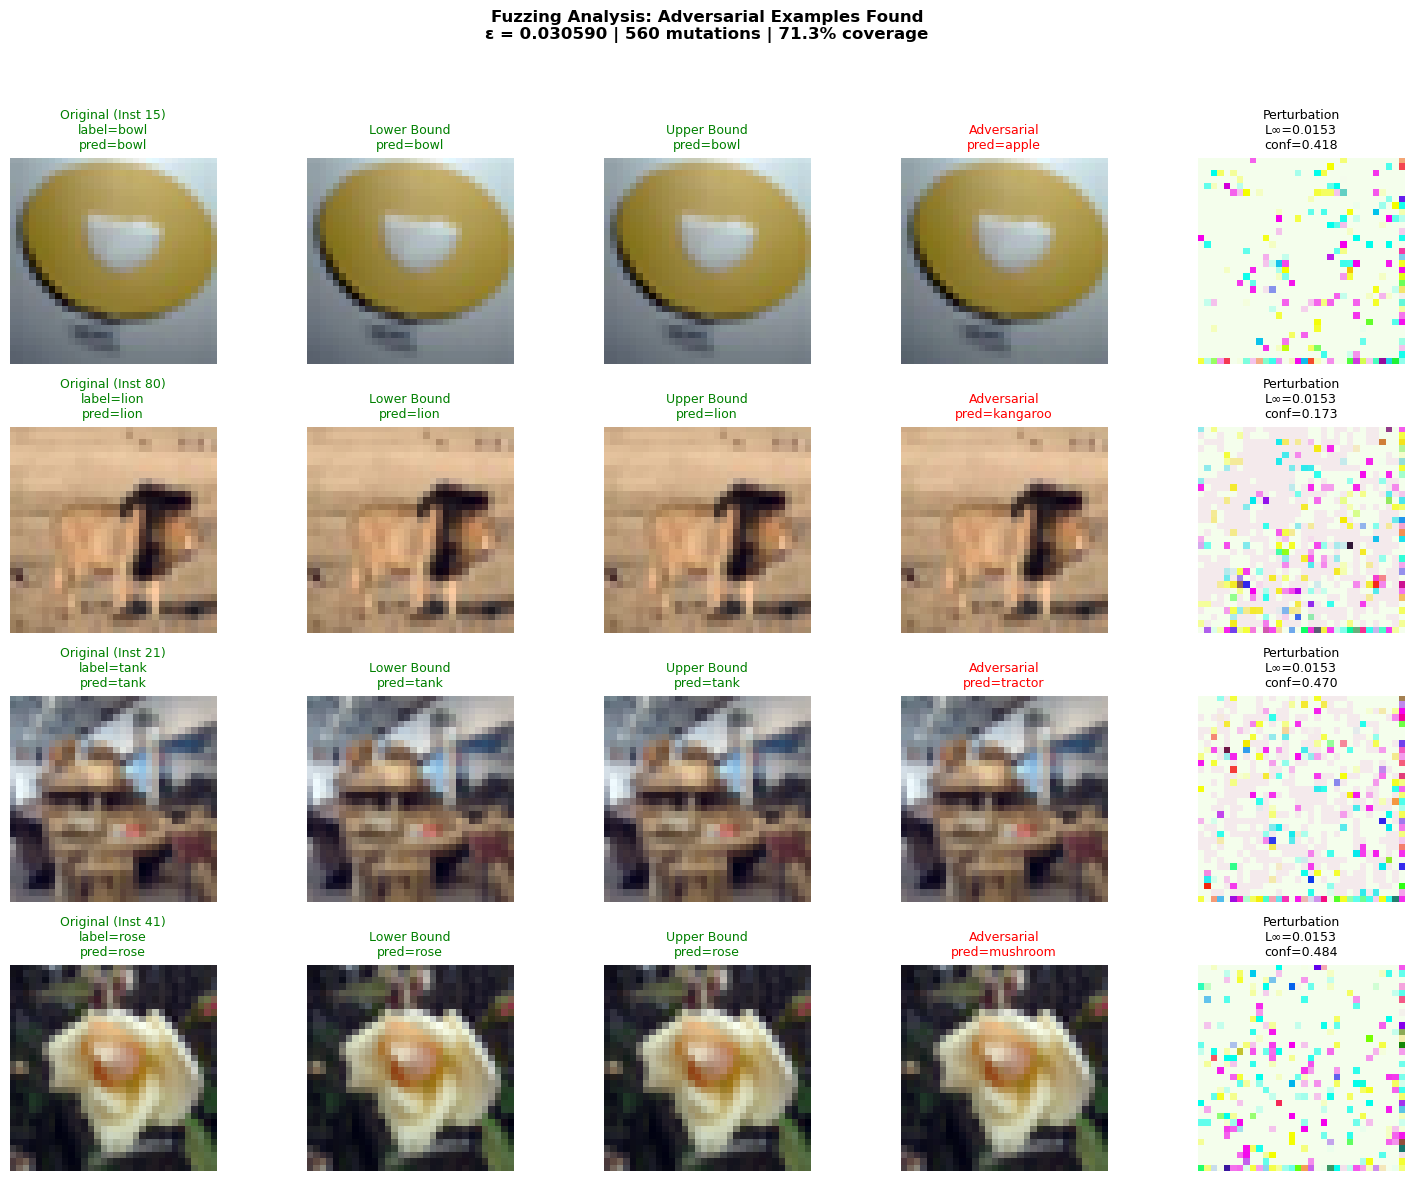

In [18]:
# Show counterexamples with Original | LB | UB | Adversarial | Perturbation

CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

def vis_norm(tensor):
    t_min = tensor.min()
    t_max = tensor.max()
    if (t_max - t_min).abs() < 1e-8:
        return tensor.permute(1,2,0).detach().cpu().numpy()
    return ((tensor - t_min) / (t_max - t_min + 1e-8)).permute(1,2,0).detach().cpu().numpy()

def find_closest_original(adv_tensor, images_tensor):
    min_dist = float('inf')
    closest_idx = 0
    adv = adv_tensor.cpu()
    for i in range(len(images_tensor)):
        orig = images_tensor[i].cpu()
        dist = (adv - orig).abs().max().item()
        if dist < min_dist:
            min_dist = dist
            closest_idx = i
    return closest_idx, min_dist

# Select diverse counterexamples: one per unique original image
diverse_ces = []
seen_originals = set()
for ce in fuzz_report.counterexamples:
    adv_tmp = ce.input.squeeze().cpu()
    if adv_tmp.dim() == 1:
        adv_tmp = adv_tmp.reshape(3, 32, 32)
    orig_idx, _ = find_closest_original(adv_tmp, images)
    if orig_idx not in seen_originals:
        seen_originals.add(orig_idx)
        diverse_ces.append(ce)
    if len(diverse_ces) >= 4:
        break

num_ce_to_show = len(diverse_ces)
print(f'Total CEs: {len(fuzz_report.counterexamples)}, unique originals: {len(seen_originals)}')
print(f'Showing {num_ce_to_show} diverse counterexamples\n')

if num_ce_to_show > 0:
    statement = (
        f'Fuzzing Analysis: Adversarial Examples Found\n'
        f'\u03b5 = {eps:.6f} | '
        f'{fuzz_report.total_mutations} mutations | {fuzz_report.neuron_coverage:.1%} coverage'
    )
    fig, axes = plt.subplots(num_ce_to_show, 5, figsize=(15, 3*num_ce_to_show))
    fig.suptitle(statement, fontsize=12, fontweight='bold', y=0.98)
    if num_ce_to_show == 1:
        axes = axes.reshape(1, -1)
    
    for row, ce in enumerate(diverse_ces):
        adv = ce.input.squeeze().cpu()
        if adv.dim() == 1:
            adv = adv.reshape(3, 32, 32)
        
        closest_idx, l_inf_dist = find_closest_original(adv, images)
        orig = images[closest_idx].cpu()
        if orig.dim() == 1:
            orig = orig.reshape(3, 32, 32)
        
        lower_bound = orig - eps
        upper_bound = orig + eps
        
        with torch.no_grad():
            orig_out = raw_model(orig.unsqueeze(0).to(device))
            orig_pred = orig_out.argmax().item()
            lb_out = raw_model(lower_bound.unsqueeze(0).to(device))
            lb_pred = lb_out.argmax().item()
            ub_out = raw_model(upper_bound.unsqueeze(0).to(device))
            ub_pred = ub_out.argmax().item()
            adv_out = raw_model(adv.unsqueeze(0).to(device))
            adv_pred = adv_out.argmax().item()
        
        orig_np = vis_norm(orig)
        adv_np = vis_norm(adv)
        lower_bound_np = vis_norm(lower_bound)
        upper_bound_np = vis_norm(upper_bound)
        
        diff = (adv - orig).abs()
        diff_np = (diff / (diff.max() + 1e-8)).permute(1, 2, 0).numpy()

        axes[row, 0].imshow(np.clip(orig_np, 0, 1))
        axes[row, 0].set_title(
            f'Original (Inst {closest_idx+1})\nlabel={CIFAR100_CLASSES[ce.expected]}\npred={CIFAR100_CLASSES[orig_pred]}',
            fontsize=9, color='green'
        )
        axes[row, 0].axis('off')

        axes[row, 1].imshow(np.clip(lower_bound_np, 0, 1))
        lb_color = 'red' if lb_pred != ce.expected else 'green'
        axes[row, 1].set_title(
            f'Lower Bound\npred={CIFAR100_CLASSES[lb_pred]}', fontsize=9, color=lb_color
        )
        axes[row, 1].axis('off')

        axes[row, 2].imshow(np.clip(upper_bound_np, 0, 1))
        ub_color = 'red' if ub_pred != ce.expected else 'green'
        axes[row, 2].set_title(
            f'Upper Bound\npred={CIFAR100_CLASSES[ub_pred]}', fontsize=9, color=ub_color
        )
        axes[row, 2].axis('off')

        axes[row, 3].imshow(np.clip(adv_np, 0, 1))
        axes[row, 3].set_title(
            f'Adversarial\npred={CIFAR100_CLASSES[adv_pred]}', fontsize=9, color='red'
        )
        axes[row, 3].axis('off')

        axes[row, 4].imshow(diff_np)
        axes[row, 4].set_title(f'Perturbation\nL\u221e={l_inf_dist:.4f}\nconf={ce.confidence:.3f}', fontsize=9)
        axes[row, 4].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print('No counterexamples to visualize - model is robust!')
    print(f'\nFuzzing Summary:')
    print(f'  - Iterations: {fuzz_report.total_iterations}')
    print(f'  - Total mutations: {fuzz_report.total_mutations}')
    print(f'  - Seeds explored: {fuzz_report.seeds_explored}')
    print(f'  - Neuron coverage: {fuzz_report.neuron_coverage:.2%}')
    print(f'  - Time: {fuzz_report.total_time:.1f}s')

Trace file: ../act/pipeline/log/fuzzing_results/traces_1.json
Found 1 trace file(s). Starting analysis...

TRACE ANALYSIS - Batched Fuzzing Run
✅ Loaded 112 traces from traces_1.json

📊 Summary Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Traces:        112
  Iterations:          0 → 555
  Violations Found:    19
  Coverage Range:      67.0% → 71.3%
  Final Coverage:      71.3%

🔄 Mutation Strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  gradient        :  48 (42.9%)
  activation      :  32 (28.6%)
  pgd             :  32 (28.6%)




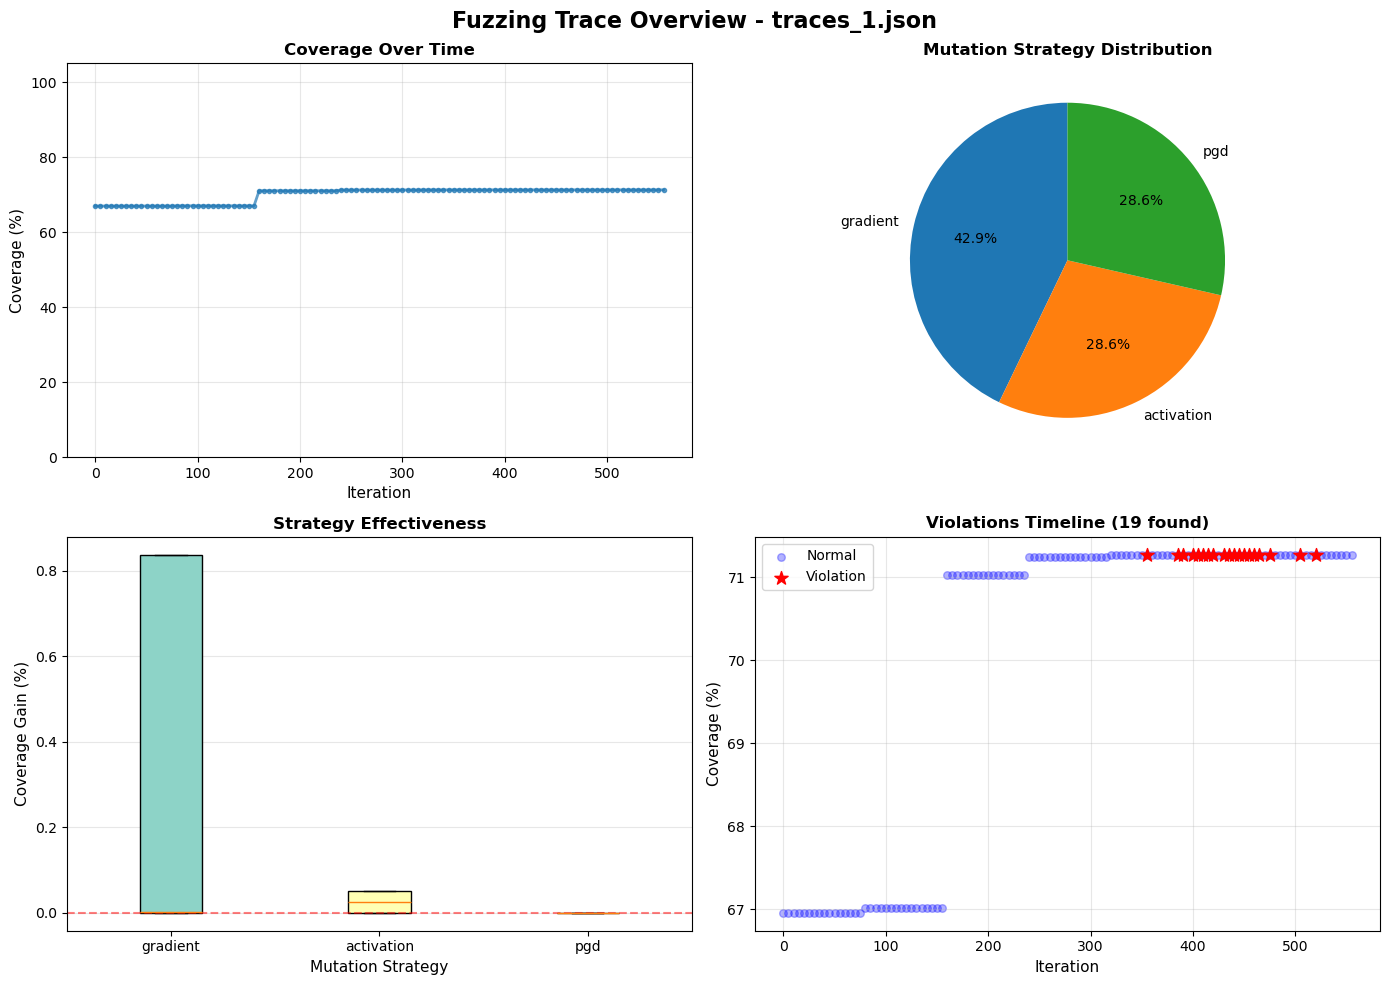


Top 5 Coverage Gains:


,trace_idx,iteration,strategy,coverage,coverage_delta
0,0,0,gradient,0.669595,0.00837
1,1,5,gradient,0.669595,0.00837
2,2,10,gradient,0.669595,0.00837
3,3,15,gradient,0.669595,0.00837
4,4,20,gradient,0.669595,0.00837



Strategy Comparison:


,Avg Gain,Std Dev,Max Gain,Count
strategy,,,,
gradient,0.0028,0.0040,0.0084,48
activation,0.0003,0.0003,0.0005,32
pgd,0.0000,0.0000,0.0000,32



Violation Analysis: 19 violations found


,trace_idx,iteration,strategy,coverage
71,71,355,pgd,0.712726
77,77,385,pgd,0.712726
78,78,390,pgd,0.712726
80,80,400,pgd,0.712726
81,81,405,pgd,0.712726
82,82,410,pgd,0.712726
83,83,415,pgd,0.712726
84,84,420,pgd,0.712726
86,86,430,pgd,0.712726
87,87,435,pgd,0.712726



Strategy Distribution:


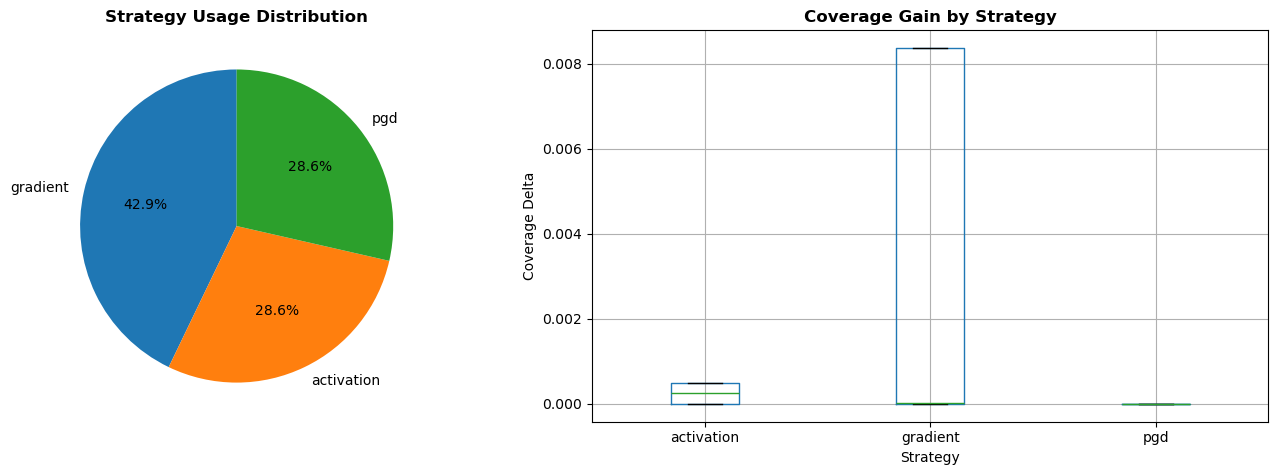

In [19]:
from pathlib import Path
import pandas as pd

# Get trace file path from the fuzzer's tracer (handles auto-generated paths)
trace_files = []
if hasattr(fuzzer, 'tracer') and fuzzer.tracer is not None:
    trace_path = fuzzer.tracer.output_path
    if trace_path.exists():
        trace_files.append(trace_path)
        print(f'Trace file: {os.path.relpath(trace_path)}')

if len(trace_files) > 0:
    print(f'Found {len(trace_files)} trace file(s). Starting analysis...')
    
    from act.pipeline.fuzzing.trace_reader import TraceAnalyzer
    
    for idx, trace_file in enumerate(trace_files):
        if not Path(trace_file).exists():
            continue
        
        print(f'\n{"="*80}')
        print(f'TRACE ANALYSIS - Batched Fuzzing Run')
        print(f'{"="*80}')
        
        analyzer = TraceAnalyzer(trace_file)
        analyzer.show_overview()
        print('\n')
        
        try:
            analyzer.plot_overview()
        except Exception as e:
            print(f'Could not generate plots: {e}')
        
        df = analyzer.to_dataframe()
        if len(df) > 0:
            print(f'\nTop 5 Coverage Gains:')
            top_traces = df.nlargest(min(5, len(df)), 'coverage_delta')[
                ['trace_idx', 'iteration', 'strategy', 'coverage', 'coverage_delta']
            ]
            display(top_traces)
            
            print(f'\nStrategy Comparison:')
            strategy_stats = df.groupby('strategy').agg({
                'coverage_delta': ['mean', 'std', 'max'],
                'trace_idx': 'count'
            }).round(4)
            strategy_stats.columns = ['Avg Gain', 'Std Dev', 'Max Gain', 'Count']
            display(strategy_stats.sort_values('Avg Gain', ascending=False))
            
            if 'violation' in df.columns:
                violations = df[df['violation'] == True]
                if len(violations) > 0:
                    print(f'\nViolation Analysis: {len(violations)} violations found')
                    display(violations[['trace_idx', 'iteration', 'strategy', 'coverage']])
            
            print(f'\nStrategy Distribution:')
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            strategy_counts = df['strategy'].value_counts()
            ax1.pie(strategy_counts.values, labels=strategy_counts.index, autopct='%1.1f%%', startangle=90)
            ax1.set_title('Strategy Usage Distribution', fontsize=12, fontweight='bold')
            
            df.boxplot(column='coverage_delta', by='strategy', ax=ax2)
            ax2.set_title('Coverage Gain by Strategy', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Strategy')
            ax2.set_ylabel('Coverage Delta')
            plt.suptitle('')
            
            plt.tight_layout()
            plt.show()
        else:
            print('   No traces captured')
else:
    print('No trace files found. Tracing not enabled or fuzzing completed too quickly.')
    print('To enable tracing, set trace_level > 0 in FuzzingConfig')
    
    print(f'\nFuzzing Summary (from fuzz_report):')
    print(f'   Iterations: {fuzz_report.total_iterations}')
    print(f'   Total mutations: {fuzz_report.total_mutations}')
    print(f'   Seeds explored: {fuzz_report.seeds_explored}')
    print(f'   Neuron coverage: {fuzz_report.neuron_coverage:.2%}')
    print(f'   Counterexamples: {len(fuzz_report.counterexamples)}')
    print(f'   Time: {fuzz_report.total_time:.2f}s')
    print(f'   Throughput: {fuzz_report.total_iterations / fuzz_report.total_time:.1f} it/s')
    
    if fuzz_report.num_of_never_activated_neurons > 0:
        print(f'\nNever-activated neurons: {fuzz_report.num_of_never_activated_neurons}')
        if fuzz_report.never_activated_neurons:
            sample = fuzz_report.never_activated_neurons[:5]
            print(f'   Sample: {sample}')

## 6. Interactive Trace Explorer

Use the dropdown widget below to interactively browse fuzzing traces.

In [20]:
if len(trace_files) > 0:
    from act.pipeline.fuzzing.trace_reader import TraceAnalyzer
    from ipywidgets import Dropdown, VBox, HTML
    from IPython.display import display
    
    trace_file = trace_files[0]
    if Path(trace_file).exists():
        print(f'Loading Interactive Explorer...')
        analyzer = TraceAnalyzer(trace_file)
        analyzer.interactive_explorer()
    else:
        print(f'Trace file not found: {trace_file}')
else:
    print('No trace files available for interactive exploration.')
    print('Enable tracing: set trace_level > 0 in FuzzingConfig')

Loading Interactive Explorer...
